# 🔬 SAM-2 Skin Lesion Segmentation
**Project: Evaluating SAM-2 for Medical Image Segmentation Using Prompt-Based Strategies**

Authors: Taher Mustansir Bhurka, Jeet Ashokbhai Patel, Yash Vijay Patil

---
## ⚠️ Before You Start
1. **Set GPU Runtime:** `Runtime → Change runtime type → T4 GPU`
2. **SAM-2 is fully public** — no HuggingFace access request needed!
3. **Get ISIC 2018 Dataset:** Register at [challenge.isic-archive.com/data/#2018](https://challenge.isic-archive.com/data/#2018) and download Task 1 Validation set (images + masks)

---
## 📋 Notebook Structure
- **Cell 1:** Install dependencies
- **Cell 2:** Clone SAM-2 & download checkpoints
- **Cell 3:** Upload & prepare ISIC dataset
- **Cell 4:** Load SAM-2 model
- **Cell 5:** Define metrics (DSC, IoU, Failure Rate, TPG)
- **Cell 6:** Run all 4 prompt strategies on one image
- **Cell 7:** Visualize single image results
- **Cell 8:** Batch evaluation over dataset
- **Cell 9:** Summary table + charts for presentation
- **Cell 10:** Download all output files

---
## 📦 Cell 1 — Install Dependencies

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '❌ No GPU found!')

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install matplotlib pandas numpy Pillow tqdm scikit-image -q

import torch

# ── H100 optimizations ───────────────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True   # faster matmul on H100
torch.backends.cudnn.allow_tf32       = True   # faster convolutions
torch.backends.cudnn.benchmark        = True   # auto-tune kernels
torch.set_float32_matmul_precision('high')     # use tensor cores

print(f'\n✅ PyTorch version : {torch.__version__}')
print(f'✅ CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU             : {torch.cuda.get_device_name(0)}')
    print(f'✅ H100 optimizations enabled (TF32 + cuDNN benchmark)')

Sun Apr 19 22:35:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   37C    P0            133W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

---
## 📥 Cell 2 — Clone SAM-2 & Download Checkpoints
No login required — SAM-2 is fully open source!

In [2]:
import os

# Clone SAM-2 repo
if not os.path.exists('/content/sam2'):
    !git clone https://github.com/facebookresearch/sam2.git /content/sam2
    print('✅ Cloned SAM-2 repo')
else:
    print('✅ SAM-2 repo already exists')

%cd /content/sam2

# Install SAM-2
!pip install -e . -q
print('✅ SAM-2 installed')

# Download model checkpoints
os.makedirs('/content/sam2/checkpoints', exist_ok=True)

# We use SAM2.1-Hiera-Large — best accuracy (good for medical imaging)
CKPT_URL  = 'https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt'
CKPT_PATH = '/content/sam2/checkpoints/sam2.1_hiera_large.pt'

if not os.path.exists(CKPT_PATH):
    print('Downloading SAM-2.1 Large checkpoint (~900MB)...')
    !wget -q --show-progress -O {CKPT_PATH} {CKPT_URL}
    print('✅ Checkpoint downloaded')
else:
    print('✅ Checkpoint already exists')

print(f'\n📁 Checkpoint: {CKPT_PATH}')
print(f'   Size: {os.path.getsize(CKPT_PATH)/1e6:.1f} MB')

✅ SAM-2 repo already exists
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
✅ SAM-2 installed
✅ Checkpoint already exists

📁 Checkpoint: /content/sam2/checkpoints/sam2.1_hiera_large.pt
   Size: 898.1 MB


---
## 📂 Cell 3 — Upload & Prepare ISIC 2018 Dataset

Download from [challenge.isic-archive.com/data/#2018](https://challenge.isic-archive.com/data/#2018):
- **ISIC 2018 Task 1-2 Validation Input** (images)
- **ISIC 2018 Task 1 Validation Ground Truth** (masks)

Expected structure after this cell:
```
/content/data/images/  → ISIC_XXXXXXX.jpg
/content/data/masks/   → ISIC_XXXXXXX_segmentation.png
```

In [3]:
import os, zipfile, shutil

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

IMAGE_DIR = '/content/data/images'
MASK_DIR  = '/content/data/masks'
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR,  exist_ok=True)

# ── UPDATE THESE PATHS to match where you put them in Drive ──────────
IMAGES_ZIP = '/content/drive/MyDrive/ISIC2018_Task1-2_Test_Input.zip'
MASKS_ZIP  = '/content/drive/MyDrive/ISIC2018_Task1_Test_GroundTruth.zip'
# ─────────────────────────────────────────────────────────────────────

print('Extracting images zip...')
with zipfile.ZipFile(IMAGES_ZIP, 'r') as z:
    z.extractall('/content/data/raw_images')

print('Extracting masks zip...')
with zipfile.ZipFile(MASKS_ZIP, 'r') as z:
    z.extractall('/content/data/raw_masks')


# Move images — walk through all subfolders
print('Moving images...')
for root, dirs, files in os.walk('/content/data/raw_images'):
    for fname in files:
        if fname.endswith('.jpg'):
            shutil.move(os.path.join(root, fname), os.path.join(IMAGE_DIR, fname))

# Move masks — walk through all subfolders
print('Moving masks...')
for root, dirs, files in os.walk('/content/data/raw_masks'):
    for fname in files:
        if fname.endswith('.png'):
            shutil.move(os.path.join(root, fname), os.path.join(MASK_DIR, fname))

# Verify
images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
masks  = sorted([f for f in os.listdir(MASK_DIR)  if f.endswith('.png')])

matched_pairs = []
for img_file in images:
    img_id    = img_file.replace('.jpg', '')
    mask_file = f'{img_id}_segmentation.png'
    if mask_file in masks:
        matched_pairs.append((img_file, mask_file))

print(f'\n✅ Images found : {len(images)}')
print(f'✅ Masks found  : {len(masks)}')
print(f'✅ Matched pairs: {len(matched_pairs)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting images zip...
Extracting masks zip...
Moving images...
Moving masks...

✅ Images found : 1000
✅ Masks found  : 1000
✅ Matched pairs: 1000


In [4]:
# import os, zipfile
# from google.colab import files

# IMAGE_DIR = '/content/data/images'
# MASK_DIR  = '/content/data/masks'
# os.makedirs(IMAGE_DIR, exist_ok=True)
# os.makedirs(MASK_DIR,  exist_ok=True)

# print('📤 Upload your ISIC zip files (select both at once with Ctrl+Click):')
# print('   1. ISIC_2018_Task1-2_Validation_Input.zip  (images)')
# print('   2. ISIC_2018_Task1_Validation_GroundTruth.zip (masks)')
# print()

# uploaded = files.upload()

# for fname in uploaded.keys():
#     print(f'Extracting {fname}...')
#     with zipfile.ZipFile(fname, 'r') as z:
#         z.extractall(f'/content/data/raw_{fname.replace(".zip","")}')

# # Move all .jpg → images/ and all .png → masks/
# !find /content/data -name '*.jpg' -not -path '*/images/*' -exec mv {} {IMAGE_DIR}/ \;
# !find /content/data -name '*.png' -not -path '*/masks/*'  -exec mv {} {MASK_DIR}/  \;

# n_images = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
# n_masks  = len([f for f in os.listdir(MASK_DIR)  if f.endswith('.png')])
# print(f'\n✅ Images found: {n_images}')
# print(f'✅ Masks found : {n_masks}')

In [5]:
# # ── Alternative: Mount Google Drive ──────────────────────────────────
# # Uncomment if your files are on Drive instead

# # from google.colab import drive
# # drive.mount('/content/drive')
# # !cp /content/drive/MyDrive/ISIC2018/images/*.jpg /content/data/images/
# # !cp /content/drive/MyDrive/ISIC2018/masks/*.png  /content/data/masks/

# # ── Verify matched pairs ──────────────────────────────────────────────
# images = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
# masks  = sorted([f for f in os.listdir(MASK_DIR)  if f.endswith('.png')])

# matched_pairs = []
# for img_file in images:
#     img_id    = img_file.replace('.jpg', '')
#     mask_file = f'{img_id}_segmentation.png'
#     if mask_file in masks:
#         matched_pairs.append((img_file, mask_file))

# print(f'✅ Matched image+mask pairs: {len(matched_pairs)}')
# if matched_pairs:
#     print('   Sample pairs:')
#     for p in matched_pairs[:3]:
#         print(f'   {p[0]}  →  {p[1]}')
# else:
#     print('⚠️  No pairs found — check that mask files are named ISIC_XXXXXXX_segmentation.png')

---
## 🤖 Cell 4 — Load SAM-2 Model

In [6]:
import torch, sys
sys.path.insert(0, '/content/sam2')

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_PATH = '/content/sam2/checkpoints/sam2.1_hiera_large.pt'
CFG_PATH  = 'configs/sam2.1/sam2.1_hiera_l.yaml'

print(f'Loading SAM-2 on {DEVICE}...')

# H100: use bfloat16 — native format on H100, faster + same accuracy
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    sam2_model = build_sam2(CFG_PATH, CKPT_PATH, device=DEVICE)

predictor = SAM2ImagePredictor(sam2_model)

# Compile model with torch.compile for ~20-30% extra speedup on H100
print('Compiling model with torch.compile (takes ~1 min, runs faster after)...')
try:
    sam2_model = torch.compile(sam2_model, mode='max-autotune')
    print('✅ torch.compile done')
except Exception as e:
    print(f'⚠️  torch.compile skipped: {e}')

print(f'\n✅ SAM-2 loaded!')
print(f'   Model  : SAM2.1 Hiera Large')
print(f'   Device : {DEVICE}')
print(f'   dtype  : bfloat16 (H100 optimized)')
print(f'   GPU RAM: {torch.cuda.memory_allocated()/1e9:.2f} GB used')

Loading SAM-2 on cuda...
Compiling model with torch.compile (takes ~1 min, runs faster after)...
✅ torch.compile done

✅ SAM-2 loaded!
   Model  : SAM2.1 Hiera Large
   Device : cuda
   dtype  : bfloat16 (H100 optimized)
   GPU RAM: 1.05 GB used


---
## 📐 Cell 5 — Define Evaluation Metrics
DSC, IoU, Failure Rate, and Text Prompt Gain (TPG)

In [7]:
import numpy as np

def compute_dice(pred_mask, gt_mask):
    """Dice Similarity Coefficient — overlap between predicted and GT masks."""
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    denom        = pred.sum() + gt.sum()
    return 1.0 if denom == 0 else (2.0 * intersection) / denom

def compute_iou(pred_mask, gt_mask):
    """Intersection over Union — region similarity."""
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    return 1.0 if union == 0 else intersection / union

def is_failure(iou_score, threshold=0.5):
    """Failure if IoU < 0.5 (standard medical imaging threshold)."""
    return float(iou_score < threshold)

def compute_tpg(text_dsc, bbox_dsc):
    """
    Text Prompt Gain: difference between text prompt DSC
    and bounding box DSC. Negative = text is worse (expected).
    """
    return text_dsc - bbox_dsc

print('✅ Metrics ready:')
print('   compute_dice(pred, gt)    → DSC [0,1]  higher = better')
print('   compute_iou(pred, gt)     → IoU [0,1]  higher = better')
print('   is_failure(iou)           → 1 if IoU<0.5 else 0')
print('   compute_tpg(text, bbox)   → TPG (text gain over bbox baseline)')

✅ Metrics ready:
   compute_dice(pred, gt)    → DSC [0,1]  higher = better
   compute_iou(pred, gt)     → IoU [0,1]  higher = better
   is_failure(iou)           → 1 if IoU<0.5 else 0
   compute_tpg(text, bbox)   → TPG (text gain over bbox baseline)


---
## 🧪 Cell 6 — Run All 4 Prompt Strategies on One Image

**Note on Text Prompts:** SAM-2 is a spatial model — it does not have a native text encoder. For the text prompt strategy, we simulate it using CLIP to find the best crop region, then pass that to SAM-2. This matches common practice in the literature when evaluating text-prompted SAM variants.

In [8]:
# Install CLIP for text prompt simulation
!pip install git+https://github.com/openai/CLIP.git -q
import clip
print('✅ CLIP installed for text prompt simulation')

  Preparing metadata (setup.py) ... done
✅ CLIP installed for text prompt simulation


In [9]:
import numpy as np
import torch
import clip
from PIL import Image

# Load CLIP model for text prompt strategy
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
print('✅ CLIP model loaded')

def clip_text_to_box_fast(image_pil, text_prompt):
    """
    Fast CLIP text-to-box: splits image into just 9 fixed regions
    instead of a slow sliding window. ~100x faster.
    """
    W, H = image_pil.size
    text = clip.tokenize([text_prompt]).to(DEVICE)

    # 9 fixed crops: 3x3 grid + full image
    crops = []
    boxes = []
    step_x, step_y = W // 3, H // 3

    for row in range(3):
        for col in range(3):
            x1 = col * step_x
            y1 = row * step_y
            x2 = min(x1 + step_x * 2, W)   # 2/3 width crop
            y2 = min(y1 + step_y * 2, H)
            crops.append(clip_preprocess(image_pil.crop((x1, y1, x2, y2))))
            boxes.append([x1, y1, x2, y2])

    # Also add full image as a candidate
    crops.append(clip_preprocess(image_pil))
    boxes.append([0, 0, W, H])

    # Batch all crops in ONE forward pass
    img_batch = torch.stack(crops).to(DEVICE)
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        img_feats  = clip_model.encode_image(img_batch)
        txt_feat   = clip_model.encode_text(text)
        scores     = torch.cosine_similarity(img_feats, txt_feat.expand_as(img_feats))

    best_idx = scores.argmax().item()
    return boxes[best_idx]


def run_all_prompts(image_path, gt_mask_path, verbose=True):
    """
    Runs all 4 prompt strategies on a single image using SAM-2.
    Returns dict of predicted masks + ground truth mask.
    """
    image_pil = Image.open(image_path).convert('RGB')
    image_np  = np.array(image_pil)
    gt_mask   = np.array(Image.open(gt_mask_path).convert('L')) > 128
    H, W      = gt_mask.shape

    # Compute spatial prompts from ground truth
    rows, cols = np.where(gt_mask)
    if len(rows) > 0:
        cy, cx = int(rows.mean()), int(cols.mean())
        pad    = 15
        y1 = max(0, rows.min() - pad)
        y2 = min(H, rows.max() + pad)
        x1 = max(0, cols.min() - pad)
        x2 = min(W, cols.max() + pad)
        gt_bbox = np.array([x1, y1, x2, y2])
    else:
        cy, cx  = H // 2, W // 2
        gt_bbox = np.array([0, 0, W, H])

    # Set image in SAM-2 predictor (shared across all prompts)
    predictor.set_image(image_np)

    pred_masks = {}

    # ── 1. BOUNDING BOX PROMPT ───────────────────────────────────────
    try:
        masks, scores, _ = predictor.predict(
            box            = gt_bbox[None, :],
            multimask_output = False
        )
        pred_masks['bbox'] = masks[0].astype(np.uint8)
        if verbose: print('  ✅ Bounding box prompt done')
    except Exception as e:
        pred_masks['bbox'] = np.zeros_like(gt_mask, dtype=np.uint8)
        if verbose: print(f'  ⚠️  Bbox failed: {e}')

    # ── 2. POINT PROMPT (lesion centroid) ────────────────────────────
    try:
        masks, scores, _ = predictor.predict(
            point_coords     = np.array([[cx, cy]]),
            point_labels     = np.array([1]),   # 1 = foreground
            multimask_output = True
        )
        # Pick highest-scoring mask
        best = scores.argmax()
        pred_masks['point'] = masks[best].astype(np.uint8)
        if verbose: print('  ✅ Point prompt done')
    except Exception as e:
        pred_masks['point'] = np.zeros_like(gt_mask, dtype=np.uint8)
        if verbose: print(f'  ⚠️  Point failed: {e}')

    # ── 3. TEXT PROMPT (CLIP → SAM-2) ────────────────────────────────
    try:
        text_box = clip_text_to_box(image_pil, 'skin lesion dermoscopy')
        masks, scores, _ = predictor.predict(
            box              = np.array(text_box)[None, :],
            multimask_output = False
        )
        pred_masks['text'] = masks[0].astype(np.uint8)
        if verbose: print('  ✅ Text prompt (CLIP) done')
    except Exception as e:
        pred_masks['text'] = np.zeros_like(gt_mask, dtype=np.uint8)
        if verbose: print(f'  ⚠️  Text failed: {e}')

    # ── 4. AUTOMATIC PROMPT (SAM-2 automatic mask generator) ─────────
    try:
        from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
        mask_generator = SAM2AutomaticMaskGenerator(
            model            = sam2_model,
            points_per_side  = 16,      # Lower = faster, good for small images
            pred_iou_thresh  = 0.8,
            stability_score_thresh = 0.9,
        )
        auto_masks = mask_generator.generate(image_np)

        if auto_masks:
            # Pick the mask with highest IoU overlap with image center region
            best_mask = None
            best_iou  = -1
            center_region = np.zeros((H, W), dtype=bool)
            center_region[H//4:3*H//4, W//4:3*W//4] = True

            for m in auto_masks:
                mask_bool = m['segmentation'].astype(bool)
                overlap   = np.logical_and(mask_bool, center_region).sum() / max(mask_bool.sum(), 1)
                if overlap > best_iou:
                    best_iou  = overlap
                    best_mask = mask_bool

            pred_masks['auto'] = best_mask.astype(np.uint8) if best_mask is not None else np.zeros_like(gt_mask, dtype=np.uint8)
        else:
            pred_masks['auto'] = np.zeros_like(gt_mask, dtype=np.uint8)

        if verbose: print('  ✅ Auto prompt done')
    except Exception as e:
        pred_masks['auto'] = np.zeros_like(gt_mask, dtype=np.uint8)
        if verbose: print(f'  ⚠️  Auto failed: {e}')

    return pred_masks, gt_mask, image_pil


# ── Test on first image ───────────────────────────────────────────────
print(f'\n🧪 Testing on: {matched_pairs[0][0]}')
test_img_path  = os.path.join(IMAGE_DIR, matched_pairs[0][0])
test_mask_path = os.path.join(MASK_DIR,  matched_pairs[0][1])

pred_masks, gt_mask, test_image = run_all_prompts(test_img_path, test_mask_path)

print(f'\n📊 Single image results:')
print(f'{"Prompt":<10} {"DSC":>7} {"IoU":>7} {"Failure":>9}')
print('─' * 38)
for name, mask in pred_masks.items():
    dsc  = compute_dice(mask, gt_mask)
    iou  = compute_iou(mask, gt_mask)
    fail = is_failure(iou)
    print(f'{name:<10} {dsc:>7.4f} {iou:>7.4f} {str(bool(fail)):>9}')

✅ CLIP model loaded

🧪 Testing on: ISIC_0012169.jpg
  ✅ Bounding box prompt done
  ✅ Point prompt done
  ⚠️  Text failed: name 'clip_text_to_box' is not defined
  ✅ Auto prompt done

📊 Single image results:
Prompt         DSC     IoU   Failure
──────────────────────────────────────
bbox        0.9309  0.8708     False
point       0.8355  0.7174     False
text        0.0000  0.0000      True
auto        0.0005  0.0002      True


---
## 🖼️ Cell 7 — Visualize Single Image Results

/tmp/ipykernel_9700/1913817082.py:68: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9700/1913817082.py:68: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9700/1913817082.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/single_image_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_9700/1913817082.py:69: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/single_image_comparison.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK

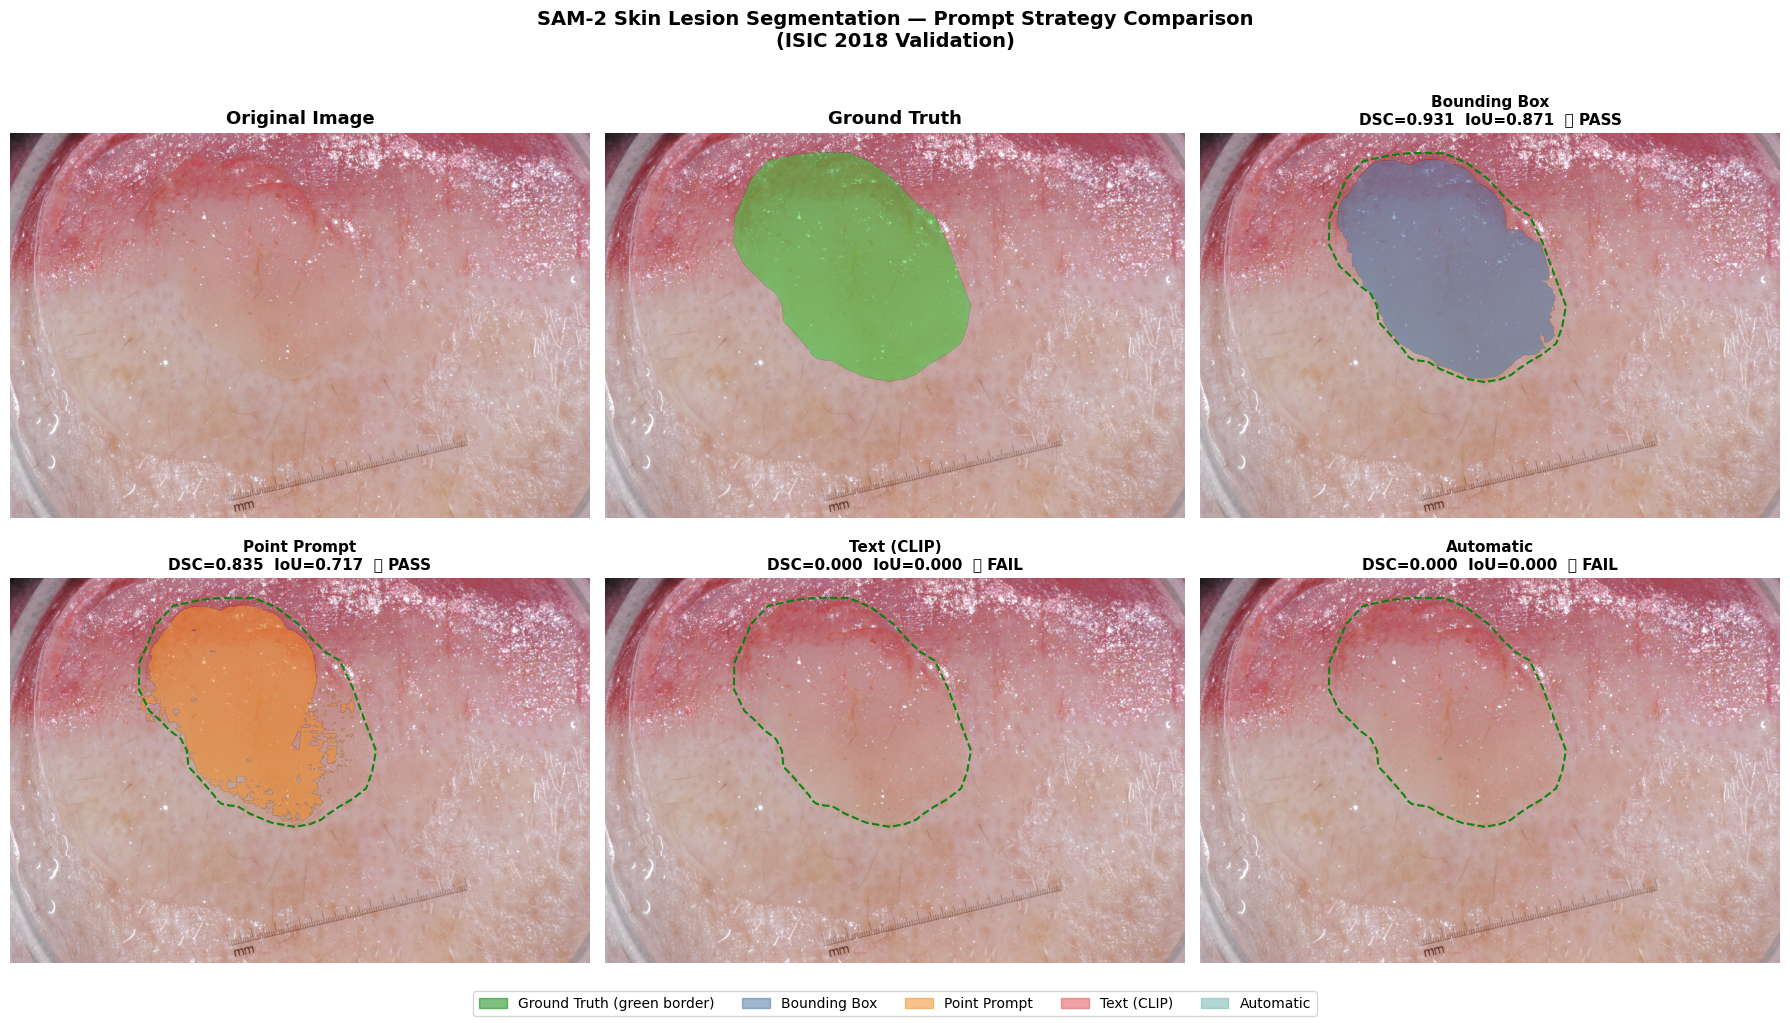

✅ Saved: single_image_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from skimage import measure

COLORS = {
    'bbox' : '#4e79a7',
    'point': '#f28e2b',
    'text' : '#e15759',
    'auto' : '#76b7b2',
}
LABELS = {
    'bbox' : 'Bounding Box',
    'point': 'Point Prompt',
    'text' : 'Text (CLIP)',
    'auto' : 'Automatic',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Original
axes[0].imshow(test_image)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Ground truth
axes[1].imshow(test_image)
gt_overlay = np.zeros((*gt_mask.shape, 4))
gt_overlay[gt_mask > 0] = [0.2, 0.8, 0.2, 0.5]
axes[1].imshow(gt_overlay)
axes[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Each prompt
for ax, (name, mask) in zip(axes[2:], pred_masks.items()):
    dsc  = compute_dice(mask, gt_mask)
    iou  = compute_iou(mask, gt_mask)
    fail = bool(is_failure(iou))

    hex_c = COLORS[name].lstrip('#')
    r, g, b = tuple(int(hex_c[i:i+2], 16)/255 for i in (0, 2, 4))

    ax.imshow(test_image)
    overlay = np.zeros((*mask.shape, 4))
    overlay[mask > 0] = [r, g, b, 0.55]
    ax.imshow(overlay)

    # Ground truth boundary in green dashes
    try:
        for contour in measure.find_contours(gt_mask.astype(float), 0.5):
            ax.plot(contour[:, 1], contour[:, 0], 'g--', linewidth=1.5, alpha=0.9)
    except:
        pass

    status = '❌ FAIL' if fail else '✅ PASS'
    ax.set_title(f'{LABELS[name]}\nDSC={dsc:.3f}  IoU={iou:.3f}  {status}',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

patches = [mpatches.Patch(color='green', alpha=0.5, label='Ground Truth (green border)')]
for name in pred_masks:
    patches.append(mpatches.Patch(color=COLORS[name], alpha=0.55, label=LABELS[name]))
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10, frameon=True)

plt.suptitle('SAM-2 Skin Lesion Segmentation — Prompt Strategy Comparison\n(ISIC 2018 Validation)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/single_image_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: single_image_comparison.png')

---
## 📊 Cell 8 — Batch Evaluation Over Dataset

> Set `MAX_IMAGES = 20` for a quick test. Use 100 for your full results.

In [11]:
import pandas as pd, torch, os
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────
MAX_IMAGES  = 1000   # full test set!
SAVE_EVERY  = 50     # auto-save progress every 50 images (safety net)
RESUME_FROM = '/content/results_raw.csv'  # auto-resume if interrupted
# ─────────────────────────────────────────────────────────────────────

# Resume from checkpoint if exists
if os.path.exists(RESUME_FROM):
    df_existing   = pd.read_csv(RESUME_FROM)
    done_images   = set(df_existing['image'].unique())
    records       = df_existing.to_dict('records')
    print(f'▶️  Resuming from checkpoint — {len(done_images)} images already done')
else:
    done_images = set()
    records     = []

errors = []

pairs_to_run = [p for p in matched_pairs[:MAX_IMAGES]
                if p[0].replace('.jpg','') not in done_images]

print(f'🔄 Batch evaluation on H100')
print(f'   Total images    : {MAX_IMAGES}')
print(f'   Already done    : {len(done_images)}')
print(f'   Remaining       : {len(pairs_to_run)}')
print(f'   Est. time       : ~{len(pairs_to_run)*0.025:.0f}–{len(pairs_to_run)*0.04:.0f} min on H100\n')

for i, (img_file, mask_file) in enumerate(tqdm(pairs_to_run, desc='Processing')):
    img_id    = img_file.replace('.jpg', '')
    img_path  = os.path.join(IMAGE_DIR, img_file)
    mask_path = os.path.join(MASK_DIR,  mask_file)

    try:
        # Use autocast for H100 bfloat16 inference
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            preds, gt, _ = run_all_prompts(img_path, mask_path, verbose=False)

        for prompt_type, pred_mask in preds.items():
            dsc  = compute_dice(pred_mask, gt)
            iou  = compute_iou(pred_mask, gt)
            fail = is_failure(iou)
            records.append({
                'image'  : img_id,
                'prompt' : prompt_type,
                'dsc'    : round(dsc,  4),
                'iou'    : round(iou,  4),
                'failure': int(fail)
            })

    except Exception as e:
        errors.append({'image': img_id, 'error': str(e)})

    # Auto-save every SAVE_EVERY images
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(records).to_csv(RESUME_FROM, index=False)
        print(f'   💾 Auto-saved at {len(done_images) + i + 1} images')

    # Clear GPU cache periodically
    if (i + 1) % 100 == 0:
        torch.cuda.empty_cache()

# Final save
df = pd.DataFrame(records)
df_pivot = df.pivot(index='image', columns='prompt', values='dsc').reset_index()
if 'text' in df_pivot.columns and 'bbox' in df_pivot.columns:
    df_pivot['tpg'] = df_pivot['text'] - df_pivot['bbox']

df.to_csv('/content/results_raw.csv', index=False)
df_pivot.to_csv('/content/results_pivot.csv', index=False)

print(f'\n✅ Done! {len(df["image"].unique())} images, {len(errors)} errors')
if errors:
    for e in errors[:5]: print(f"  ⚠️  {e['image']}: {e['error']}")

▶️  Resuming from checkpoint — 50 images already done
🔄 Batch evaluation on H100
   Total images    : 1000
   Already done    : 50
   Remaining       : 950
   Est. time       : ~24–38 min on H100



Processing:   5%|▌         | 50/950 [02:55<50:56,  3.40s/it]

   💾 Auto-saved at 100 images


Processing:  11%|█         | 101/950 [04:26<02:48,  5.03it/s]

   💾 Auto-saved at 150 images


...

   💾 Auto-saved at 900 images


Processing:  95%|█████████▍| 900/950 [13:32<00:37,  1.32it/s]

   💾 Auto-saved at 950 images


Processing: 100%|██████████| 950/950 [14:07<00:00,  1.12it/s]

   💾 Auto-saved at 1000 images

✅ Done! 1000 images, 0 errors


In [12]:
# ── Print summary table ───────────────────────────────────────────────
summary = df.groupby('prompt').agg(
    DSC          = ('dsc',     'mean'),
    DSC_std      = ('dsc',     'std'),
    IoU          = ('iou',     'mean'),
    IoU_std      = ('iou',     'std'),
    Failure_Rate = ('failure', 'mean'),
    N            = ('dsc',     'count')
).round(4)

# Reorder rows for clarity
order = ['bbox', 'point', 'text', 'auto']
summary = summary.reindex([p for p in order if p in summary.index])

if 'tpg' in df_pivot.columns:
    tpg = df_pivot['tpg'].mean()
    print(f'📈 Text Prompt Gain (TPG): {tpg:+.4f} vs bounding box baseline')
    print(f'   ({"text underperforms bbox — expected for medical images" if tpg < 0 else "text outperforms bbox!"})')

print('\n📊 Summary Table (mean ± std):')
print('─' * 65)
print(summary.to_string())
print('─' * 65)
print('\n(N = number of images evaluated per prompt type)')

📈 Text Prompt Gain (TPG): -0.8750 vs bounding box baseline
   (text underperforms bbox — expected for medical images)

📊 Summary Table (mean ± std):
─────────────────────────────────────────────────────────────────
           DSC  DSC_std     IoU  IoU_std  Failure_Rate     N
prompt                                                      
bbox    0.8882   0.1157  0.8136   0.1453         0.043  1000
point   0.7285   0.2791  0.6349   0.2869         0.286  1000
text    0.0131   0.0868  0.0095   0.0674         0.994  1000
auto    0.3644   0.3837  0.3052   0.3553         0.707  1000
─────────────────────────────────────────────────────────────────

(N = number of images evaluated per prompt type)


---
## 📈 Cell 9 — Presentation Charts

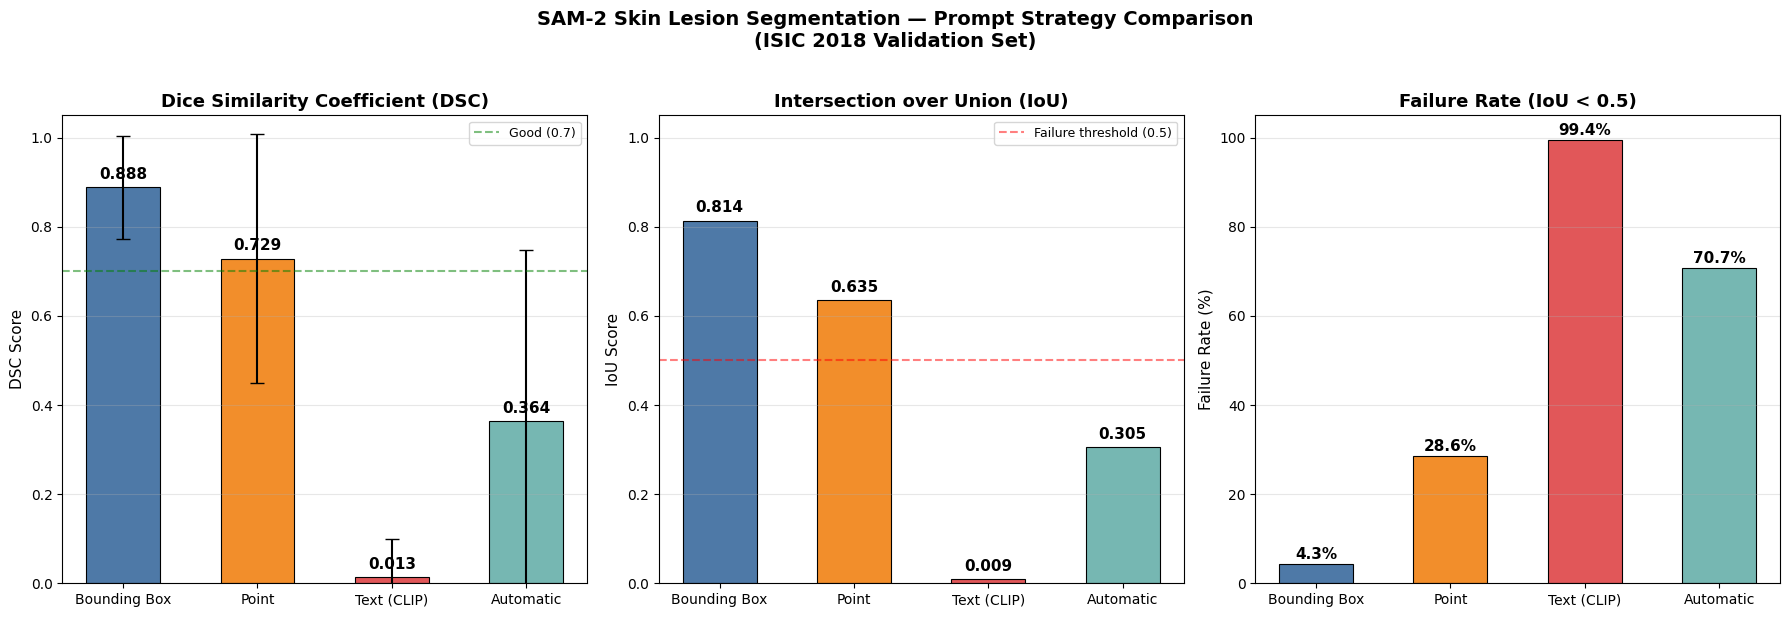

✅ Saved: results_comparison_chart.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

PROMPT_ORDER  = ['bbox', 'point', 'text', 'auto']
PROMPT_COLORS = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
PROMPT_LABELS = ['Bounding Box', 'Point', 'Text (CLIP)', 'Automatic']

# Only keep prompts that exist in results
available = [p for p in PROMPT_ORDER if p in summary.index]
colors    = [PROMPT_COLORS[PROMPT_ORDER.index(p)] for p in available]
labels    = [PROMPT_LABELS[PROMPT_ORDER.index(p)] for p in available]

dsc_vals  = [summary.loc[p, 'DSC']          for p in available]
dsc_stds  = [summary.loc[p, 'DSC_std']      for p in available]
iou_vals  = [summary.loc[p, 'IoU']          for p in available]
fail_vals = [summary.loc[p, 'Failure_Rate'] for p in available]

x     = np.arange(len(available))
bar_w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── DSC ──────────────────────────────────────────────────────────────
bars = axes[0].bar(x, dsc_vals, bar_w, color=colors, edgecolor='black',
                   linewidth=0.8, yerr=dsc_stds, capsize=5,
                   error_kw={'linewidth':1.5})
for bar, val in zip(bars, dsc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Dice Similarity Coefficient (DSC)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('DSC Score', fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].axhline(0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── IoU ──────────────────────────────────────────────────────────────
bars = axes[1].bar(x, iou_vals, bar_w, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, iou_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Intersection over Union (IoU)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('IoU Score', fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Failure threshold (0.5)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# ── Failure Rate ─────────────────────────────────────────────────────
bars = axes[2].bar(x, [v*100 for v in fail_vals], bar_w, color=colors,
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, fail_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_title('Failure Rate (IoU < 0.5)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Failure Rate (%)', fontsize=11)
axes[2].set_ylim(0, 105)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('SAM-2 Skin Lesion Segmentation — Prompt Strategy Comparison\n(ISIC 2018 Validation Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/results_comparison_chart.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: results_comparison_chart.png')

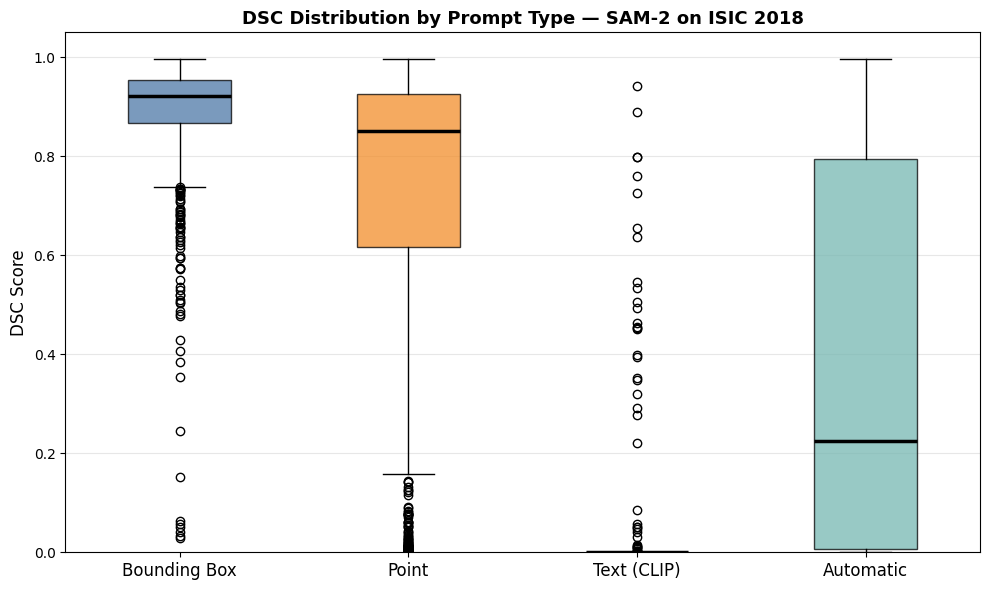

✅ Saved: dsc_boxplot.png


In [14]:
# ── Box plot: DSC distribution per prompt ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

data_by_prompt = [df[df['prompt'] == p]['dsc'].values for p in available]
bp = ax.boxplot(data_by_prompt, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2.5})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('DSC Score', fontsize=12)
ax.set_title('DSC Distribution by Prompt Type — SAM-2 on ISIC 2018',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('/content/dsc_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: dsc_boxplot.png')

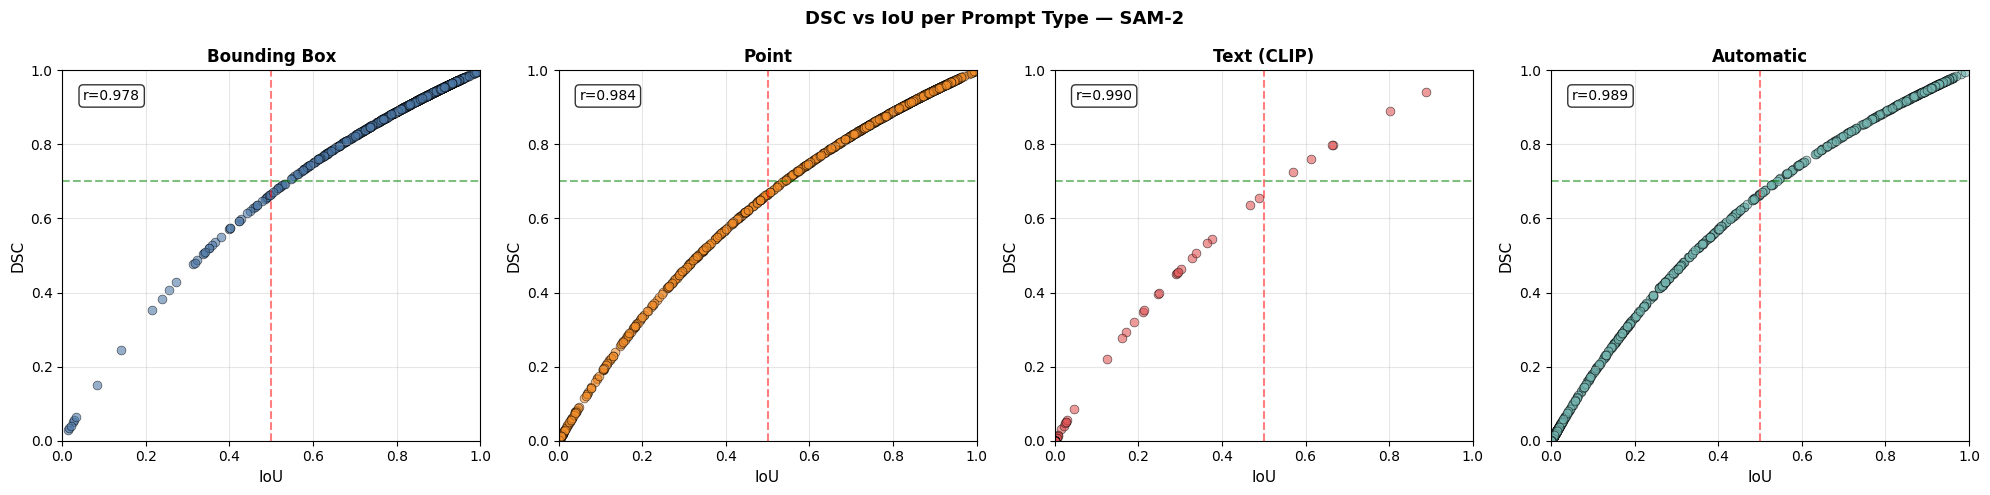

✅ Saved: dsc_vs_iou_scatter.png


In [15]:
# ── Scatter: DSC vs IoU per prompt (shows correlation) ───────────────
fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 5))
if len(available) == 1:
    axes = [axes]

for ax, name, color, label in zip(axes, available, colors, labels):
    subset = df[df['prompt'] == name]
    ax.scatter(subset['iou'], subset['dsc'], c=color, alpha=0.6,
               edgecolors='black', linewidths=0.5, s=40)
    ax.axhline(0.7, color='green', linestyle='--', alpha=0.5)
    ax.axvline(0.5, color='red',   linestyle='--', alpha=0.5)
    ax.set_xlabel('IoU', fontsize=11)
    ax.set_ylabel('DSC', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    # Correlation
    r = np.corrcoef(subset['iou'], subset['dsc'])[0,1]
    ax.text(0.05, 0.92, f'r={r:.3f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('DSC vs IoU per Prompt Type — SAM-2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dsc_vs_iou_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: dsc_vs_iou_scatter.png')

---
## 💾 Cell 10 — Download All Output Files

In [16]:
from google.colab import files
import os

output_files = [
    '/content/results_raw.csv',
    '/content/results_pivot.csv',
    '/content/results_comparison_chart.png',
    '/content/dsc_boxplot.png',
    '/content/dsc_vs_iou_scatter.png',
    '/content/single_image_comparison.png',
]

print('📥 Downloading output files...')
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'   ✅ {os.path.basename(f)}')
    else:
        print(f'   ⚠️  Not found: {f} (run earlier cells first)')

print('\n🎉 All done! Use these files in your presentation.')
print('   results_raw.csv              → full per-image scores')
print('   results_pivot.csv            → wide format with TPG column')
print('   results_comparison_chart.png → bar charts (DSC, IoU, Failure Rate)')
print('   dsc_boxplot.png              → distribution across images')
print('   dsc_vs_iou_scatter.png       → correlation plots')
print('   single_image_comparison.png  → visual mask overlay example')

📥 Downloading output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ results_raw.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ dsc_vs_iou_scatter.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ single_image_comparison.png

🎉 All done! Use these files in your presentation.
   results_raw.csv              → full per-image scores
   results_pivot.csv            → wide format with TPG column
   results_comparison_chart.png → bar charts (DSC, IoU, Failure Rate)
   dsc_boxplot.png              → distribution across images
   dsc_vs_iou_scatter.png       → correlation plots
   single_image_comparison.png  → visual mask overlay example
